In [ ]:
import pandas as pd
from utils import load_dataset_paths, load_to_df, get_longest_segment

In [5]:
file_paths = load_dataset_paths("../../data/couta_data/", file_extension="csv")
proc_ds_couta = list() 

for path in file_paths:
    proc_ds_couta.append(load_to_df(path))

longest_segments = list()
for df in proc_ds_couta:
    longest_segment = get_longest_segment(df, True)
    if len(longest_segment) < 100:
        print(f"Station {df.columns.values[0]} discarded due to insufficient data.")
    else:
        longest_segments.append(longest_segment)

    print("-" * 40)

Estación Aquatec - C Pintor Balaca:
Range: 2023-09-30 16:00:00 to 2023-10-05 13:00:00
Total time points recovered: 118
----------------------------------------
Estación Aquatec - Calle Real:
Range: 2023-06-27 15:00:00 to 2023-07-02 16:00:00
Total time points recovered: 122
----------------------------------------
Estación AQ1 - BusCT:
Range: 2022-03-15 02:00:00 to 2022-03-30 20:00:00
Total time points recovered: 379
----------------------------------------
Estación AQN3 - Paseo Alfonso XIII:
Range: 2023-07-13 00:00:00 to 2023-08-03 06:00:00
Total time points recovered: 511
----------------------------------------
Estación Aquatec - C Serreta:
Range: 2023-10-20 06:00:00 to 2023-10-30 19:00:00
Total time points recovered: 254
----------------------------------------
Estación AQN6 - C. Jiménez de la Espada, 43:
Range: 2022-10-09 15:00:00 to 2022-10-24 08:00:00
Total time points recovered: 354
----------------------------------------
Estación Aquatec - C San Diego:
Range: 2023-08-09 00:00:

https://unit8co.github.io/darts/#forecasting-models

In [ ]:
from utils import apply_symmetric_gaps,impute_prophet, impute_iterative, impute_lgbm, smape

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
from typing import List

from joblib import Parallel, delayed
import multiprocessing

sizes_to_test = [1, 2, 5, 10]
iterations = 30
accumulated_results = list()

def evaluate_methods_single(original: pd.DataFrame, with_gaps: pd.DataFrame) -> pd.DataFrame:
    results = list()

    methods = {
        "Linear": lambda df: df.interpolate(method='linear'),
        "Spline": lambda df: df.interpolate(method='spline', order=3),
        "Polynomial": lambda df: df.interpolate(method='polynomial', order=2),
        "Prophet": lambda df: df.apply(impute_prophet),
        "IterativeImputer": lambda df: impute_iterative(df),
        "LightGBM": lambda df: df.apply(lambda col: impute_lgbm(col, window_length=10))
    }

    col = original.columns[0]

    for name, func in methods.items():
        df_imputed = func(with_gaps.copy())

        deleted_points = with_gaps[col].isna()

        y_real = original.loc[deleted_points, col]
        y_pred = df_imputed.loc[deleted_points, col]

        if len(y_real) > 0:
            rmse = np.sqrt(mean_squared_error(y_real, y_pred))
            mae = mean_absolute_error(y_real, y_pred)
            smape_val = smape(y_real.values, y_pred.values)

            results.append({
                "Method": name,
                "Series": original.columns[0],
                "RMSE": rmse,
                "MAE": mae,
                "SMAPE": smape_val
            })

    return pd.DataFrame(results)


def run_experiment_list(i: int, k: int, df_list: List[pd.DataFrame]):
    results = []

    for idx, df in enumerate(df_list):
        seed = (i * 10_000_000 + idx * 10_000 + k) % (2**32)
        df_gaps = apply_symmetric_gaps(
            df,
            num_gaps=50,
            size_k=k,
            rng=np.random.default_rng(seed)
        )

        df_res = evaluate_methods_single(
            df,
            df_gaps
        )

        df_res['Size_K'] = k
        df_res['Iteration'] = i

        results.append(df_res)

    return pd.concat(results, ignore_index=True)


combinations = [
    (i, k)
    for i in range(iterations)
    for k in sizes_to_test
]

num_cores = multiprocessing.cpu_count()

accumulated_results = Parallel(n_jobs=num_cores)(
    delayed(run_experiment_list)(i, k, longest_segments)
    for i, k in combinations
)

df_benchmark = pd.concat(accumulated_results, ignore_index=True)

/home/daniel/Documents/airquality/.venv/lib/python3.11/site-packages/pandas/core/missing.py:604: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  terp = interpolate.UnivariateSpline(x, y, k=order, **kwargs)
/home/daniel/Documents/airquality/.venv/lib/python3.11/site-packages/pandas/core/missing.py:604: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  terp = interpolate.UnivariateSpline(x, y, k=order, **kwargs)
/home/daniel/Documents/airquality/.venv/lib/python3.11/site-packages/pandas/co

In [26]:
df_benchmark

,Method,Series,RMSE,MAE,SMAPE,Size_K,Iteration
0,Linear,Aquatec - C Pintor Balaca,42.523171,29.678270,26.093145,1,0
1,Spline,Aquatec - C Pintor Balaca,41.885402,32.637390,26.313770,1,0
2,Polynomial,Aquatec - C Pintor Balaca,40.302985,31.061777,25.507341,1,0
3,Prophet,Aquatec - C Pintor Balaca,50.139730,38.415103,32.726081,1,0
4,IterativeImputer,Aquatec - C Pintor Balaca,90.352806,73.939847,48.526609,1,0
...,...,...,...,...,...,...,...
15835,Spline,Aquatec - Plaza Juan XXIII,62.372078,41.813390,17.510695,10,29
15836,Polynomial,Aquatec - Plaza Juan XXIII,60.895270,42.496973,17.942316,10,29
15837,Prophet,Aquatec - Plaza Juan XXIII,32.586749,24.118669,10.695928,10,29
15838,IterativeImputer,Aquatec - Plaza Juan XXIII,36.307739,29.079149,12.934958,10,29


In [ ]:
df_final_stats = (
    df_benchmark
    .groupby(['Method', 'Size_K'])
    .agg({
        'RMSE': ['mean','std'],
        'MAE': ['mean','std'],
        'SMAPE': ['mean','std']
    })
    .reset_index()
)

df_final_stats

Method Size_K       RMSE                   MAE             \
                                  mean        std       mean        std   
0   IterativeImputer      1  46.932505  19.883442  36.332768  15.409269   
1   IterativeImputer      2  47.092189  20.006774  36.236483  15.246877   
2   IterativeImputer      5  46.978019  19.257331  36.326016  14.931845   
3   IterativeImputer     10  47.269792  19.839542  36.052888  15.142012   
4           LightGBM      1  63.476066  40.456196  51.336285  39.409757   
5           LightGBM      2  63.269228  40.639636  51.067091  39.363602   
6           LightGBM      5  62.019709  38.553137  50.599171  37.502248   
7           LightGBM     10  65.704822  39.880694  53.719300  38.588437   
8             Linear      1  22.828125  10.329329  15.793870   6.778318   
9             Linear      2  28.565206  11.916879  19.807164   8.063237   
10            Linear      5  41.908557  18.244584  29.950845  13.063722   
11            Linear     10  53.829451  24.788277  39.599239  18.962076   
12        Polynomial      1  23.395762  11.363956  16.184190   7.336878   
13        Polynomial      2  30.414592  13.147130  21.164959   8.922806   
14        Polynomial      5  51.536483  21.535148  36.421688  15.189415   
15        Polynomial     10  81.123731  37.319534  57.319709  26.024195   
16           Prophet      1  33.365150  14.012674  25.399921  10.153152   
17           Prophet      2  34.680341  14.050708  26.181824  10.126847   
18           Prophet      5  36.254451  13.643396  27.592912  10.026173   
19           Prophet     10  39.108642  15.156369  30.114040  11.636543   
20            Spline      1  23.955406  11.680120  16.653022   7.611766   
21            Spline      2  30.715760  13.373510  21.571903   9.146768   
22            Spline      5  52.452836  22.114587  37.442352  15.800595   
23            Spline     10  82.604074  38.481647  58.860680  27.087729   

        SMAPE             
         mean        std  
0   16.823527   6.680971  
1   16.707004   6.634021  
2   16.745030   6.308138  
3   16.533888   6.366175  
4   21.943547  10.651654  
5   21.811920  10.816325  
6   21.867043  10.516102  
7   23.178009  11.123216  
8    7.519352   3.690152  
9    9.267551   4.337259  
10  13.825901   6.106595  
11  17.852677   8.114104  
12   7.763839   4.069550  
13  10.192004   5.141223  
14  17.706930   8.199906  
15  27.718198  14.091178  
16  11.965990   4.996634  
17  12.308581   5.072473  
18  12.862396   4.444137  
19  14.230364   6.134500  
20   8.026808   4.313944  
21  10.406489   5.241104  
22  18.272383   8.578413  
23  28.624244  14.978655

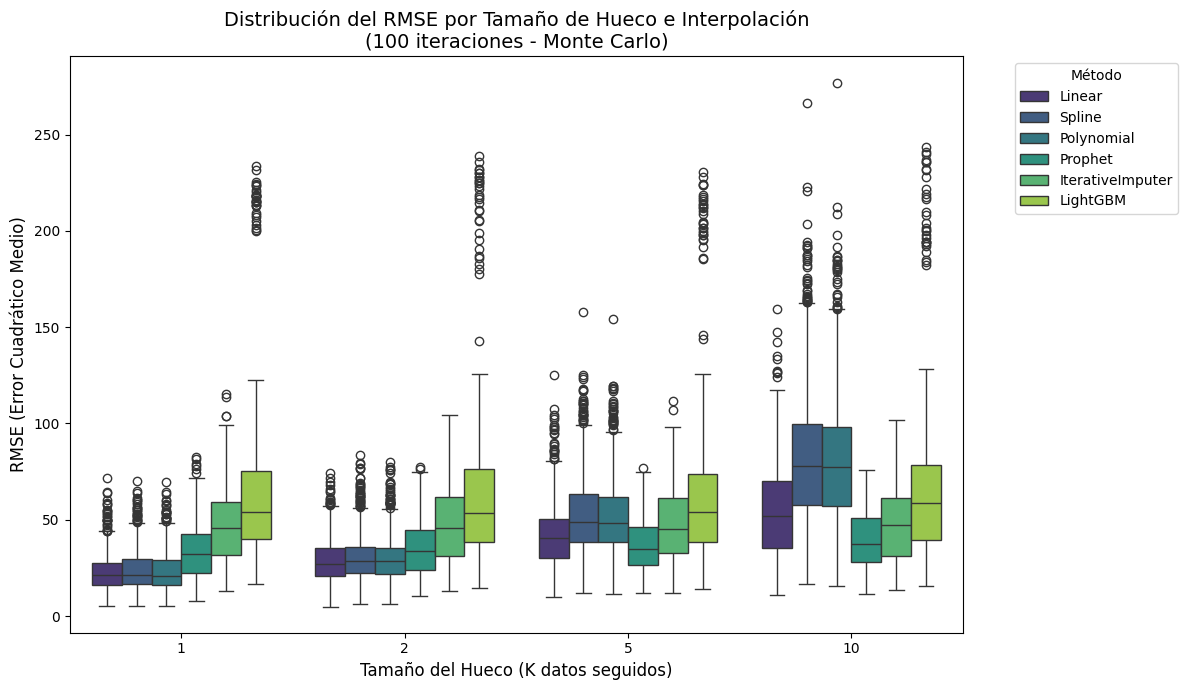

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de estilo
#sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Generación del Boxplot
# Usamos df_benchmark porque contiene todas las iteraciones (no el df_final_stats)
ax = sns.boxplot(
    data=df_benchmark, 
    x='Size_K', 
    y='RMSE', 
    hue='Method',
    palette='viridis',
    showfliers=True
)

# Personalización de ejes y títulos
plt.title('Distribución del RMSE por Tamaño de Hueco e Interpolación\n(100 iteraciones - Monte Carlo)', fontsize=14)
plt.xlabel('Tamaño del Hueco (K datos seguidos)', fontsize=12)
plt.ylabel('RMSE (Error Cuadrático Medio)', fontsize=12)
plt.legend(title='Método', bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()

In [23]:
# Comparación global simple
ranking = (
    df_benchmark
    .groupby(['Method', 'Size_K'])['RMSE']
    .mean()
    .reset_index()
)

ranking['Rank'] = ranking.groupby('Size_K')['RMSE']\
                          .rank(method='average')

print(ranking.sort_values(['Size_K','Rank']))

              Method  Size_K       RMSE  Rank
8             Linear       1  22.828125   1.0
12        Polynomial       1  23.395762   2.0
20            Spline       1  23.955406   3.0
16           Prophet       1  33.365150   4.0
0   IterativeImputer       1  46.932505   5.0
4           LightGBM       1  63.476066   6.0
9             Linear       2  28.565206   1.0
13        Polynomial       2  30.414592   2.0
21            Spline       2  30.715760   3.0
17           Prophet       2  34.680341   4.0
1   IterativeImputer       2  47.092189   5.0
5           LightGBM       2  63.269228   6.0
18           Prophet       5  36.254451   1.0
10            Linear       5  41.908557   2.0
2   IterativeImputer       5  46.978019   3.0
14        Polynomial       5  51.536483   4.0
22            Spline       5  52.452836   5.0
6           LightGBM       5  62.019709   6.0
19           Prophet      10  39.108642   1.0
3   IterativeImputer      10  47.269792   2.0
11            Linear      10  53.8

In [24]:
# Ranking promedio global
ranking_global = (
    ranking
    .groupby('Method')['Rank']
    .mean()
    .reset_index()
    .sort_values('Rank')
)

print(ranking_global)


             Method  Rank
2            Linear  1.75
4           Prophet  2.50
3        Polynomial  3.25
0  IterativeImputer  3.75
5            Spline  4.25
1          LightGBM  5.50


In [25]:
# Considerar estabilidad
estabilidad = (
    df_benchmark
    .groupby(['Method', 'Size_K'])['RMSE']
    .std()
    .reset_index()
)

# score combinado penaliza métodos inestables
resumen = (
    df_benchmark
    .groupby(['Method', 'Size_K'])['RMSE']
    .agg(['mean','std'])
    .reset_index()
)

resumen['Score'] = resumen['mean'] + resumen['std']
resumen = resumen.sort_values('Score')

print(resumen)


              Method  Size_K       mean        std       Score
8             Linear       1  22.828125  10.329329   33.157454
12        Polynomial       1  23.395762  11.363956   34.759718
20            Spline       1  23.955406  11.680120   35.635525
9             Linear       2  28.565206  11.916879   40.482085
13        Polynomial       2  30.414592  13.147130   43.561722
21            Spline       2  30.715760  13.373510   44.089271
16           Prophet       1  33.365150  14.012674   47.377823
17           Prophet       2  34.680341  14.050708   48.731049
18           Prophet       5  36.254451  13.643396   49.897846
19           Prophet      10  39.108642  15.156369   54.265011
10            Linear       5  41.908557  18.244584   60.153141
2   IterativeImputer       5  46.978019  19.257331   66.235349
0   IterativeImputer       1  46.932505  19.883442   66.815947
1   IterativeImputer       2  47.092189  20.006774   67.098963
3   IterativeImputer      10  47.269792  19.839542   67

In [27]:
from scipy.stats import friedmanchisquare

# Crear matriz método x escenario
pivot = (
    df_benchmark
    .groupby(['Method','Series','Size_K'])['RMSE']
    .mean()
    .reset_index()
    .pivot_table(index=['Series','Size_K'],
                 columns='Method',
                 values='RMSE')
)

friedmanchisquare(*[pivot[col] for col in pivot.columns])# Si el p-valor < 0.05 existen diferencias significativas.

FriedmanchisquareResult(statistic=np.float64(178.7012987012988), pvalue=np.float64(1.0134133657277558e-36))